# P2 Text Preprocessing - Phase 5

## Chocolate Deep-Dive

This notebook expands the Phase 4 chocolate work by comparing language across chocolate types and by analyzing common two-word phrases (bigrams).

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import polars as pl

In [2]:
ROOT_PATH = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT_PATH / "data"
input_path = DATA_PATH / "text_data_phase5.txt"

lines = input_path.read_text(encoding="utf-8").splitlines()
lines = [line.strip() for line in lines if line.strip()]

records = []
for line in lines:
    parts = [part.strip() for part in line.split("|", maxsplit=1)]
    if len(parts) == 2 and parts[0] and parts[1]:
        records.append({"chocolate_type": parts[0].lower(), "review_text": parts[1]})

reviews_df = pl.DataFrame(records)
raw_text = " ".join(reviews_df["review_text"].to_list())

print(f"Loaded {len(reviews_df):,} chocolate reviews from {input_path.name}")
print(reviews_df.head(5))

Loaded 15 chocolate reviews from text_data_phase5.txt
shape: (5, 2)
┌────────────────┬─────────────────────────────────┐
│ chocolate_type ┆ review_text                     │
│ ---            ┆ ---                             │
│ str            ┆ str                             │
╞════════════════╪═════════════════════════════════╡
│ dark           ┆ Rich cocoa aroma with roasted … │
│ dark           ┆ Bittersweet profile with cherr… │
│ dark           ┆ High cacao bar with earthy dep… │
│ dark           ┆ Velvety melt with orange zest,… │
│ milk           ┆ Creamy body with caramel sweet… │
└────────────────┴─────────────────────────────────┘


In [3]:
STOP_WORDS = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "for",
    "from",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "to",
    "was",
    "were",
    "will",
    "with",
    "bar",
    "notes",
    "note",
    "flavor",
    "finish",
    "profile",
    "texture",
}


def preprocess_tokens(text: str) -> list[str]:
    lower_value = text.lower()
    no_punct_value = re.sub(r"[^a-z0-9\s]", " ", lower_value)
    tokens = no_punct_value.split()
    return [tok for tok in tokens if len(tok) > 2 and tok not in STOP_WORDS]

In [4]:
raw_tokens = raw_text.split()
count_of_raw_tokens = len(raw_tokens)

lower_text = raw_text.lower()
no_punct_text = re.sub(r"[^a-z0-9\s]", " ", lower_text)
tokens_no_punct = no_punct_text.split()
count_of_tokens_no_punct = len(tokens_no_punct)

token_rows = []
for row in reviews_df.iter_rows(named=True):
    row_tokens = preprocess_tokens(row["review_text"])
    for token in row_tokens:
        token_rows.append({"chocolate_type": row["chocolate_type"], "token": token})

token_df = pl.DataFrame(token_rows)
clean_tokens = token_df["token"].to_list()
count_of_clean_tokens = len(clean_tokens)

summary_df = pl.DataFrame(
    {
        "stage": ["raw tokens", "after punctuation removal", "after stop word removal"],
        "count": [count_of_raw_tokens, count_of_tokens_no_punct, count_of_clean_tokens],
    }
)

print(summary_df)

shape: (3, 2)
┌───────────────────────────┬───────┐
│ stage                     ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ i64   │
╞═══════════════════════════╪═══════╡
│ raw tokens                ┆ 143   │
│ after punctuation removal ┆ 145   │
│ after stop word removal   ┆ 95    │
└───────────────────────────┴───────┘


In [5]:
freq_df = token_df.group_by("token").len().sort("len", descending=True)

by_type_df = (
    token_df.group_by(["chocolate_type", "token"])
    .len()
    .sort(["chocolate_type", "len", "token"], descending=[False, True, False])
    .with_columns(pl.cum_count("token").over("chocolate_type").alias("rank"))
    .filter(pl.col("rank") <= 5)
)

bigrams = [
    f"{clean_tokens[i]} {clean_tokens[i + 1]}" for i in range(len(clean_tokens) - 1)
]
bigram_df = (
    pl.DataFrame({"bigram": bigrams})
    .group_by("bigram")
    .len()
    .sort("len", descending=True)
)

print("Top 12 tokens:")
print(freq_df.head(12))
print("\nTop tokens by chocolate type:")
print(by_type_df)
print("\nTop 10 bigrams:")
print(bigram_df.head(10))

Top 12 tokens:
shape: (12, 2)
┌───────────┬─────┐
│ token     ┆ len │
│ ---       ┆ --- │
│ str       ┆ u64 │
╞═══════════╪═════╡
│ cocoa     ┆ 6   │
│ sweetness ┆ 4   │
│ aroma     ┆ 3   │
│ vanilla   ┆ 3   │
│ creamy    ┆ 2   │
│ …         ┆ …   │
│ sweet     ┆ 2   │
│ smooth    ┆ 2   │
│ subtle    ┆ 2   │
│ sugar     ┆ 1   │
│ structure ┆ 1   │
└───────────┴─────┘

Top tokens by chocolate type:
shape: (15, 4)
┌────────────────┬─────────────┬─────┬──────┐
│ chocolate_type ┆ token       ┆ len ┆ rank │
│ ---            ┆ ---         ┆ --- ┆ ---  │
│ str            ┆ str         ┆ u64 ┆ u64  │
╞════════════════╪═════════════╪═════╪══════╡
│ dark           ┆ cocoa       ┆ 4   ┆ 1    │
│ dark           ┆ acidity     ┆ 1   ┆ 2    │
│ dark           ┆ almond      ┆ 1   ┆ 3    │
│ dark           ┆ aroma       ┆ 1   ┆ 4    │
│ dark           ┆ bittersweet ┆ 1   ┆ 5    │
│ …              ┆ …           ┆ …   ┆ …    │
│ white          ┆ sweetness   ┆ 2   ┆ 1    │
│ white          ┆ vanilla     ┆

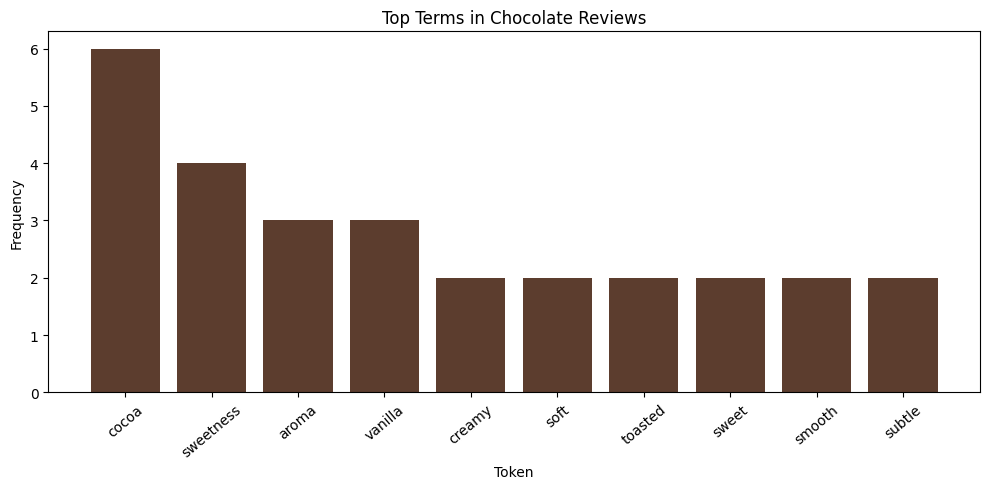

In [6]:
top_df = freq_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_df["token"], top_df["len"], color="#5c3d2e")
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=40)
plt.title("Top Terms in Chocolate Reviews")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

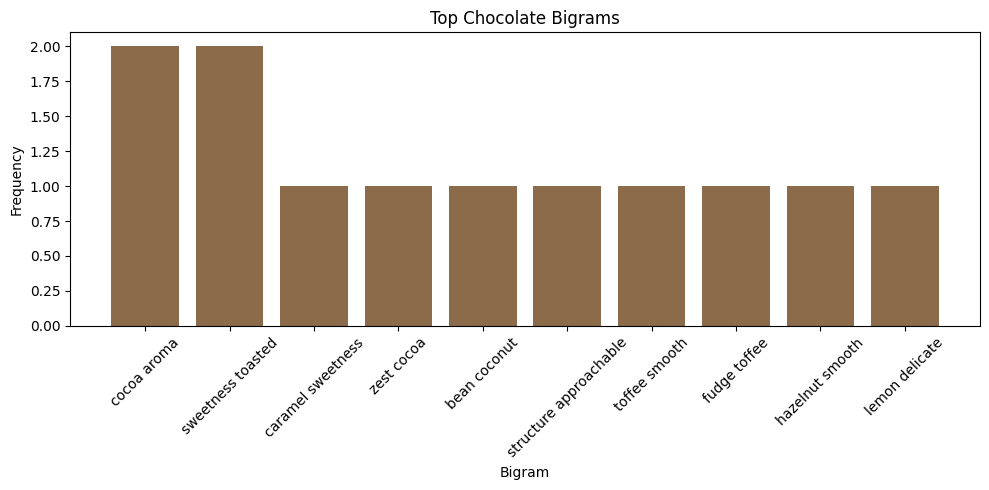

In [7]:
top_bigram_df = bigram_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_bigram_df["bigram"], top_bigram_df["len"], color="#8b6b4a")
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)
plt.title("Top Chocolate Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Phase 5 Reflection

This phase demonstrates independent application by extending the original method with:
1. A richer chocolate dataset with labeled review types.
2. Type-based token comparison across dark, milk, and white chocolate.
3. Phrase-level analysis using bigrams to capture flavor context.